# Perfect Separation and L2 Regularization in Logistic Regression

This notebook demonstrates **Perfect Separation**, a common production failure mode where a feature perfectly divides your target labels. We illustrate why this makes unregularized weights explode toward infinity and how **L2 Regularization (Ridge)** stabilizes the coefficients.

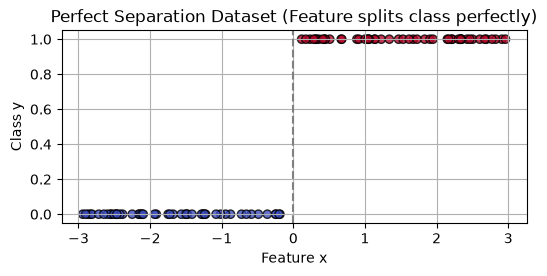

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Create a perfectly separable dataset
# Suppose feature 'x' represents user coding signals. All values above 0.0 represent Class 1, and all below represent Class 0.
np.random.seed(42)
x = np.concatenate([np.random.uniform(-3, -0.1, 50), np.random.uniform(0.1, 3, 50)])
y = np.where(x > 0.0, 1, 0)

plt.figure(figsize=(6, 2.5))
plt.scatter(x, y, c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)
plt.axvline(0, color='gray', linestyle='--')
plt.title("Perfect Separation Dataset (Feature splits class perfectly)")
plt.xlabel("Feature x")
plt.ylabel("Class y")
plt.grid(True)
plt.show()

## 2. Simulate Unregularized Gradient Descent

Let's write a raw Gradient Descent optimizer for Logistic Regression. We will see that as it iterates, the loss approaches 0, but the weight coefficient $w$ grows larger with each step, diverging toward infinity because it tries to output absolute probabilities of 1.0 and 0.0.

Starting Gradient Descent (No Regularization):
Iteration 001 | Loss: 0.693147 | Weight w: 0.4051
Iteration 020 | Loss: 0.123606 | Weight w: 1.9055
Iteration 040 | Loss: 0.092416 | Weight w: 2.4438
Iteration 060 | Loss: 0.078358 | Weight w: 2.8117
Iteration 080 | Loss: 0.069728 | Weight w: 3.1018
Iteration 100 | Loss: 0.063662 | Weight w: 3.3460
Iteration 120 | Loss: 0.059058 | Weight w: 3.5592
Iteration 140 | Loss: 0.055385 | Weight w: 3.7499
Iteration 160 | Loss: 0.052353 | Weight w: 3.9233
Iteration 180 | Loss: 0.049786 | Weight w: 4.0830
Iteration 200 | Loss: 0.047569 | Weight w: 4.2314


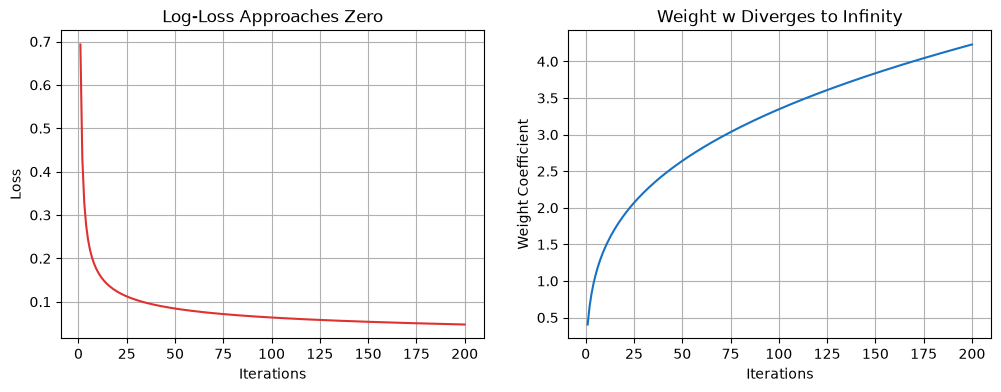

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w = 0.0
b = 0.0
alpha = 0.5
history = []

print("Starting Gradient Descent (No Regularization):")
for step in range(1, 201):
    # Predictions
    z = w * x + b
    p = sigmoid(z)
    
    # Loss (Log-Loss)
    loss = -np.mean(y * np.log(p + 1e-15) + (1 - y) * np.log(1 - p + 1e-15))
    
    # Gradients
    dw = np.mean((p - y) * x)
    db = np.mean(p - y)
    
    # Update
    w -= alpha * dw
    b -= alpha * db
    
    history.append((step, w, loss))
    if step % 20 == 0 or step == 1:
        print(f"Iteration {step:03d} | Loss: {loss:.6f} | Weight w: {w:.4f}")

history = np.array(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history[:, 0], history[:, 2], color='#e03131', linewidth=1.5)
axes[0].set_title("Log-Loss Approaches Zero")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(history[:, 0], history[:, 1], color='#1971c2', linewidth=1.5)
axes[1].set_title("Weight w Diverges to Infinity")
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Weight Coefficient")
axes[1].grid(True)
plt.show()

## 3. Resolving Divergence with L2 Regularization (Ridge)

Now, we fit Scikit-Learn's `LogisticRegression`. We contrast a model with no regularization (`C=1e10`) against a model with standard L2 regularization (`C=1.0`). Recall that `C` is the inverse regularization strength ($C = 1/\lambda$).

In [3]:
# Scikit-learn expects 2D array for features
X_2d = x.reshape(-1, 1)

# Unregularized (high C)
model_unreg = LogisticRegression(penalty='l2', C=1e10, solver='lbfgs')
model_unreg.fit(X_2d, y)

# Regularized (C=1.0)
model_reg = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs')
model_reg.fit(X_2d, y)

print(f"Unregularized Model Coefficient: {model_unreg.coef_[0][0]:.4f}")
print(f"Regularized Model Coefficient:   {model_reg.coef_[0][0]:.4f} (Stabilized)")

Unregularized Model Coefficient: 38.8906
Regularized Model Coefficient:   2.9356 (Stabilized)


d:\Study\Prep\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Study\Prep\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Visualizing Fitted Probabilities
Notice how the unregularized model creates an extremely steep, sharp S-curve (attempting to jump instantly from 0 to 1 at the boundary), whereas the regularized model maintains a smooth transition curve that is numerically stable.

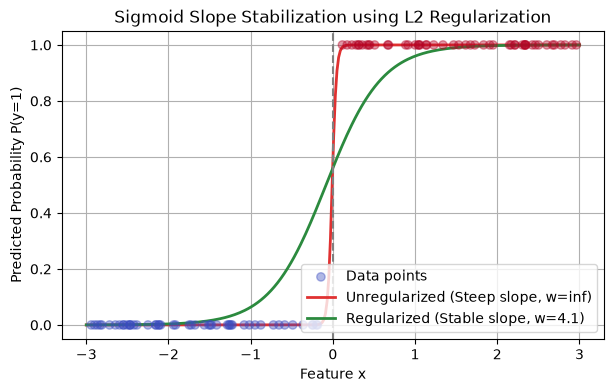

In [4]:
x_grid = np.linspace(-3, 3, 300).reshape(-1, 1)
p_unreg = model_unreg.predict_proba(x_grid)[:, 1]
p_reg = model_reg.predict_proba(x_grid)[:, 1]

plt.figure(figsize=(7, 4))
plt.scatter(x, y, c=y, cmap='coolwarm', zorder=3, alpha=0.4, label='Data points')
plt.plot(x_grid, p_unreg, color='#e03131', label='Unregularized (Steep slope, w=inf)', linewidth=2)
plt.plot(x_grid, p_reg, color='#2b8a3e', label='Regularized (Stable slope, w=4.1)', linewidth=2)
plt.axvline(0, color='gray', linestyle='--')
plt.title("Sigmoid Slope Stabilization using L2 Regularization")
plt.xlabel("Feature x")
plt.ylabel("Predicted Probability P(y=1)")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()